# Patch2Prod Arena — Small Scale SFT Training

This notebook runs a **small supervised fine-tuning (SFT)** job for Patch2Prod Arena.

Goal: teach a small model to output valid JSON action sequences that look like the risk-aware/reference policy.

Recommended runtime: **Colab GPU / T4**.

Outputs produced:

- `outputs/sft_patch2prod/` — SFT checkpoint
- `artifacts/plots/loss_curve.png` — required training plot
- `artifacts/traces/sft_trace.json` — model evaluation trace
- optionally pushes model to Hugging Face Hub


## 0. Check GPU

In [1]:
!nvidia-smi || true
!python --version

Sat Apr 25 19:21:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Clone your repo

Replace the GitHub URL with your actual repo if needed. If you already uploaded the repo to Colab, skip this cell and `%cd` into it.

In [2]:
GITHUB_REPO = "https://github.com/Ria-R/patch2prod-arena.git"

from pathlib import Path

if not Path('/content/patch2prod_arena').exists():
    !git clone $GITHUB_REPO /content/patch2prod_arena

%cd /content/patch2prod_arena

Cloning into '/content/patch2prod_arena'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 85 (delta 21), reused 78 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 305.59 KiB | 3.73 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/patch2prod_arena


## 2. Install dependencies

In [3]:
from pathlib import Path

p = Path("pyproject.toml")
if p.exists():
    text = p.read_text()
    text = text.replace('requires-python = ">=3.10,<3.12"', 'requires-python = ">=3.10,<3.13"')
    p.write_text(text)
    !grep -n "requires-python" pyproject.toml || true

!pip install -q -U pip
!pip install -q torch transformers datasets accelerate trl peft huggingface_hub matplotlib pandas numpy
!pip install -q -e .

!python -c "from patch2prod.env import Patch2ProdEnv; print('Patch2ProdEnv import OK')"

9:requires-python = ">=3.10,<3.13"
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for patch2prod-arena (pyproject.toml) ... done
Patch2ProdEnv import OK


## 3. Hugging Face login

Use a **write token** only if you want to push the trained checkpoint to HF. Do not paste tokens into notebook cells.

In [4]:
from huggingface_hub import notebook_login
notebook_login()

## 4. Create SFT data if missing

This creates a tiny `data/sft_traces.jsonl` using the two current Patch2Prod tasks. If your repo already has this file, this cell keeps it.

In [5]:
AVAILABLE_ACTIONS = [
    "view_log", "view_commit_history", "view_diff", "cat",
    "view_migration_guide", "view_security_advisory", "replace",
    "run_unit_tests", "view_dependency_graph", "mark_impacted_service",
    "run_contract_tests", "view_ownership_map", "submit_causal_change",
    "submit_blast_radius", "submit_release_decision",
]

def build_prompt(task_id, service, failure, step, visible_state, available_actions=AVAILABLE_ACTIONS):
    failed_job = visible_state.get("failed_job", "unit-tests")

    first_action_hint = ""
    if (
        visible_state.get("pipeline_status") == "failed"
        and not visible_state.get("discovered", {}).get("viewed_logs")
    ):
        first_action_hint = f"""
For this state, no logs have been viewed yet.
The next action should inspect the failed job log using the failed_job value.

Expected next action:
{{"action_type":"view_log","params":{{"job_name":"{failed_job}"}}}}

Do NOT use params like:
{{"log_file_path":"..."}}
{{"log_entry":"..."}}
"""

    return f"""You are a release engineering agent in Patch2Prod Arena.

Task ID: {task_id}
Service: {service}
Step: {step}
Failure context: {failure}

Current state:
{json.dumps(visible_state, indent=2)}

Available actions:
{json.dumps(available_actions)}

Rules:
- Output ONE JSON object only.
- No markdown.
- No explanation.
- No code blocks.
- No comments.
- Use ONLY actions from the available_actions list.
- Stop immediately after the closing brace.
- The JSON must match this schema exactly:
{{"action_type":"<action>","params":{{...}}}}

Important parameter names:
- view_log uses: {{"job_name":"{failed_job}"}}
- view_diff uses: {{"commit_id":"c42"}} or {{"commit_id":"p17"}}
- cat uses: {{"file_path":"app/retry.py"}} or {{"file_path":"app/payment_response.py"}}
- replace uses: {{"file_path":"...","search":"...","replace":"..."}}
- run_unit_tests uses: {{"service":"{service}"}}
- view_dependency_graph uses: {{"service":"{service}"}}
- run_contract_tests uses: {{"service":"<downstream-service>"}}
- submit_blast_radius uses: {{"impacted_services":["service-a","service-b"]}}
- submit_release_decision uses: {{"decision":"ship|block|canary","reason":"...","owner":"..."}}

{first_action_hint}

Your action:"""

In [15]:
import json
from pathlib import Path

Path("data").mkdir(exist_ok=True)
sft_path = Path("data/sft_traces.jsonl")

STEP_EXAMPLES = []

def completion(action_type, **params):
    return json.dumps(
        {"action_type": action_type, "params": params},
        separators=(",", ":"),
    )

def add_example(task_id, task_service, variant, failure, step, visible_state, action_type, **params):
    STEP_EXAMPLES.append({
        "task_id": task_id,
        "variant": variant,
        "prompt": build_prompt(
            task_id=task_id,
            service=task_service,
            failure=failure,
            step=step,
            visible_state=visible_state,
            available_actions=AVAILABLE_ACTIONS,
        ),
        "completion": completion(action_type, **params),
    })

# ─────────────────────────────────────────────────────────────────────────────
# Task 1: authsdk_mobile_contract_break
# ─────────────────────────────────────────────────────────────────────────────

BASE_OBS_AUTH = {
    "task_id": "authsdk_mobile_contract_break",
    "service": "auth-service",
    "pipeline_status": "failed",
    "failed_job": "unit-tests",
    "problem": "auth-service CI fails after authsdk v2 upgrade",
}

auth_log_failures = [
    "ImportError: cannot import name 'build_retry_policy' from 'authsdk.helpers'",
    "auth-service unit-tests failing after authsdk upgrade",
    "build_retry_policy no longer importable from authsdk.helpers",
    "The auth-service build is red because app/retry.py imports build_retry_policy.",
    "Unit tests fail immediately after authsdk was upgraded to v2.",
    "The pipeline is failed and no investigation has been done. First inspect the failed unit-tests log.",
    "The build is red. Start by viewing the failed unit-tests job.",
    "No logs have been viewed yet. Inspect the failed job log.",
]
for i, failure_desc in enumerate(auth_log_failures, 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_view_log_{i}",
        failure_desc,
        1,
        {**BASE_OBS_AUTH, "discovered": {}, "validations": {}},
        "view_log",
        job_name="unit-tests",
    )

auth_commit_contexts = [
    "Log shows ImportError for build_retry_policy. Need to find what changed.",
    "ImportError from authsdk.helpers. Check recent commits to find the upgrade.",
    "The failed symbol is from authsdk. Inspect commit history before patching.",
    "The error started after a dependency migration. Find the failing change.",
]
for i, context in enumerate(auth_commit_contexts, 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_view_commit_history_{i}",
        context,
        2,
        {
            **BASE_OBS_AUTH,
            "discovered": {"viewed_logs": ["unit-tests"]},
            "last_result": {"log": "ImportError: cannot import name 'build_retry_policy'"},
        },
        "view_commit_history",
    )

for i, context in enumerate([
    "Recent commits show c42 upgraded authsdk and the pipeline started failing.",
    "Commit history shows c42 is the first failing commit after authsdk upgrade.",
    "The likely causal commit is c42. Inspect its diff.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_view_diff_{i}",
        context,
        3,
        {
            **BASE_OBS_AUTH,
            "discovered": {"viewed_logs": ["unit-tests"], "viewed_commits": True},
            "last_result": {"recent_changes": [
                {"commit": "c41", "summary": "Refactor retry tests", "status": "passing"},
                {"commit": "c42", "summary": "Upgrade authsdk 1.8 to 2.0", "status": "failing"},
            ]},
        },
        "view_diff",
        commit_id="c42",
    )

for i, context in enumerate([
    "Inspect the file that imports build_retry_policy.",
    "Need to see app/retry.py before applying the migration fix.",
    "The failing stack points to app/retry.py.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_cat_{i}",
        context,
        4,
        {
            **BASE_OBS_AUTH,
            "discovered": {"viewed_logs": ["unit-tests"], "viewed_commits": True},
            "last_result": {"diff_summary": "authsdk upgraded from 1.8.0 to 2.0.0"},
        },
        "cat",
        file_path="app/retry.py",
    )

for i, context in enumerate([
    "Need authsdk v2 migration guidance before patching.",
    "The symbol changed during SDK migration. Read migration guide.",
    "Check docs for the authsdk v2 replacement API.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_migration_guide_{i}",
        context,
        5,
        {
            **BASE_OBS_AUTH,
            "discovered": {
                "viewed_logs": ["unit-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/retry.py"],
            },
            "last_result": {"content": "from authsdk.helpers import build_retry_policy"},
        },
        "view_migration_guide",
    )

for i, context in enumerate([
    "Migration guide says build_retry_policy was renamed to create_retry_policy.",
    "Patch app/retry.py to use create_retry_policy.",
    "Apply the renamed authsdk helper fix.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_replace_{i}",
        context,
        6,
        {
            **BASE_OBS_AUTH,
            "discovered": {
                "viewed_logs": ["unit-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/retry.py"],
            },
            "last_result": {"migration_guide": "build_retry_policy was renamed to create_retry_policy"},
        },
        "replace",
        file_path="app/retry.py",
        search="build_retry_policy",
        replace="create_retry_policy",
    )

for i, context in enumerate([
    "The import patch is applied. Verify local CI.",
    "Run auth-service unit tests after the retry helper replacement.",
    "Check whether the local auth-service build is now green.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_run_unit_tests_{i}",
        context,
        7,
        {
            **BASE_OBS_AUTH,
            "changed_files": ["app/retry.py"],
            "current_diff": "build_retry_policy replaced with create_retry_policy",
        },
        "run_unit_tests",
        service="auth-service",
    )

for i, context in enumerate([
    "Local CI passes. Inspect downstream release risk.",
    "The build is green. Check dependency graph before shipping.",
    "CI is green, but auth-service may affect downstream consumers.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_view_dependency_graph_{i}",
        context,
        8,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "passed",
            "changed_files": ["app/retry.py"],
            "validations": {"unit:auth-service": "passed"},
        },
        "view_dependency_graph",
        service="auth-service",
    )

auth_impacted = ["checkout-service", "mobile-gateway", "fraud-service"]

for idx, svc in enumerate(auth_impacted):
    for j, context in enumerate([
        f"Dependency graph shows {svc} is downstream of auth-service.",
        f"Mark {svc} as impacted by auth-service token behavior.",
    ], 1):
        add_example(
            "authsdk_mobile_contract_break",
            "auth-service",
            f"auth_mark_{svc}_{j}",
            context,
            9 + idx,
            {
                **BASE_OBS_AUTH,
                "pipeline_status": "passed",
                "discovered": {
                    "viewed_dependency_graph": True,
                    "marked_impacted": auth_impacted[:idx],
                },
            },
            "mark_impacted_service",
            service=svc,
            reason="Downstream consumer of auth-service token behavior",
        )

for i, context in enumerate([
    "All impacted auth-service downstream consumers have been identified.",
    "Submit the blast radius for auth-service change.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_submit_blast_radius_{i}",
        context,
        12,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "passed",
            "discovered": {
                "viewed_dependency_graph": True,
                "marked_impacted": auth_impacted,
            },
        },
        "submit_blast_radius",
        impacted_services=auth_impacted,
    )

for idx, svc in enumerate(auth_impacted):
    for j, context in enumerate([
        f"Run targeted contract validation for impacted service {svc}.",
        f"Validate downstream contract for {svc}.",
    ], 1):
        previous_validations = {f"contract:{s}": "passed" for s in auth_impacted[:idx]}
        add_example(
            "authsdk_mobile_contract_break",
            "auth-service",
            f"auth_contract_{svc}_{j}",
            context,
            13 + idx,
            {
                **BASE_OBS_AUTH,
                "pipeline_status": "passed",
                "discovered": {"submitted_blast_radius": auth_impacted},
                "validations": previous_validations,
            },
            "run_contract_tests",
            service=svc,
        )

for i, context in enumerate([
    "Release decision: mobile-gateway contract failed after authsdk v2 token expiry behavior change.",
    "Local CI passes but mobile-gateway contract failed. Decide release.",
    "Downstream validation failed for mobile-gateway. Submit safe release decision.",
], 1):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_release_block_{i}",
        context,
        16,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "passed",
            "validations": {
                "unit:auth-service": "passed",
                "contract:checkout-service": "passed",
                "contract:mobile-gateway": "failed",
                "contract:fraud-service": "passed",
            },
        },
        "submit_release_decision",
        decision="block",
        owner="mobile-platform",
        reason="Local CI passes but mobile-gateway contract fails after authsdk v2 token_expiry format change",
    )

# ─────────────────────────────────────────────────────────────────────────────
# Task 2: payment_schema_checkout_break
# ─────────────────────────────────────────────────────────────────────────────

BASE_OBS_PAY = {
    "task_id": "payment_schema_checkout_break",
    "service": "payment-service",
    "pipeline_status": "failed",
    "failed_job": "integration-tests",
    "problem": "payment-service schema migration breaks checkout contract",
}

pay_log_failures = [
    "AssertionError: expected field 'payment_status', got 'status'.",
    "checkout expects payment_status but payment-service only returns status.",
    "payment-service integration-tests fail after renaming payment_status to status.",
    "Checkout contract validation fails because payment_status is missing.",
    "payment-service emits status only, but downstream expects payment_status.",
    "The pipeline is failed and no investigation has been done. First inspect the failed integration-tests log.",
    "The build is red. Start by viewing the failed integration-tests job.",
    "No logs have been viewed yet. Inspect the failed payment integration-tests log.",
]
for i, failure_desc in enumerate(pay_log_failures, 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_view_log_{i}",
        failure_desc,
        1,
        {**BASE_OBS_PAY, "discovered": {}, "validations": {}},
        "view_log",
        job_name="integration-tests",
    )

for i, context in enumerate([
    "The log shows payment_status is missing. Inspect recent changes.",
    "Schema contract broke after a rename. Check recent commits.",
    "Need to identify which commit changed payment response schema.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_view_commit_history_{i}",
        context,
        2,
        {
            **BASE_OBS_PAY,
            "discovered": {"viewed_logs": ["integration-tests"]},
            "last_result": {"log": "AssertionError: expected field 'payment_status', got 'status'"},
        },
        "view_commit_history",
    )

for i, context in enumerate([
    "Recent commit p17 renamed payment_status to status.",
    "Commit p17 is the likely schema-change culprit.",
    "Inspect the diff for p17.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_view_diff_{i}",
        context,
        3,
        {
            **BASE_OBS_PAY,
            "discovered": {"viewed_logs": ["integration-tests"], "viewed_commits": True},
            "last_result": {
                "recent_changes": [
                    {"commit": "p17", "summary": "Rename payment_status to status", "status": "failing"}
                ]
            },
        },
        "view_diff",
        commit_id="p17",
    )

for i, context in enumerate([
    "Inspect payment response serialization.",
    "Need to read app/payment_response.py.",
    "The schema failure points to payment response output.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_cat_{i}",
        context,
        4,
        {
            **BASE_OBS_PAY,
            "discovered": {"viewed_logs": ["integration-tests"], "viewed_commits": True},
            "last_result": {"diff_summary": "payment_status renamed to status"},
        },
        "cat",
        file_path="app/payment_response.py",
    )

for i, context in enumerate([
    "Need migration guide for payment schema compatibility.",
    "Check migration docs before patching schema change.",
    "Determine how to preserve backward compatibility for one release window.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_migration_guide_{i}",
        context,
        5,
        {
            **BASE_OBS_PAY,
            "discovered": {
                "viewed_logs": ["integration-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/payment_response.py"],
            },
            "last_result": {"content": "return {'status': p.status, 'id': p.id}"},
        },
        "view_migration_guide",
    )

for i, context in enumerate([
    "Migration guide says emit both payment_status and status for one release window.",
    "Patch payment response to preserve backward compatibility.",
    "Add payment_status back while keeping status.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_replace_{i}",
        context,
        6,
        {
            **BASE_OBS_PAY,
            "discovered": {
                "viewed_logs": ["integration-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/payment_response.py"],
            },
            "last_result": {"migration_guide": "Emit both payment_status and status for one release window."},
        },
        "replace",
        file_path="app/payment_response.py",
        search="return {'status': p.status, 'id': p.id}",
        replace="return {'status': p.status, 'payment_status': p.status, 'id': p.id}",
    )

for i, context in enumerate([
    "The backward-compatible schema patch is applied. Verify local CI.",
    "Run payment-service tests after restoring payment_status.",
    "Check if payment-service integration tests pass after patch.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_run_unit_tests_{i}",
        context,
        7,
        {
            **BASE_OBS_PAY,
            "changed_files": ["app/payment_response.py"],
            "current_diff": "payment_status restored alongside status",
        },
        "run_unit_tests",
        service="payment-service",
    )

for i, context in enumerate([
    "Local CI passes. Inspect downstream consumers for schema risk.",
    "The build is green. Check payment-service dependency graph.",
    "Need downstream blast radius before release decision.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_view_dependency_graph_{i}",
        context,
        8,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "passed",
            "validations": {"unit:payment-service": "passed"},
        },
        "view_dependency_graph",
        service="payment-service",
    )

pay_impacted = ["checkout-service", "fraud-service"]

for idx, svc in enumerate(pay_impacted):
    for j, context in enumerate([
        f"Dependency graph shows {svc} consumes payment-service output.",
        f"Mark {svc} as impacted by payment schema change.",
    ], 1):
        add_example(
            "payment_schema_checkout_break",
            "payment-service",
            f"pay_mark_{svc}_{j}",
            context,
            9 + idx,
            {
                **BASE_OBS_PAY,
                "pipeline_status": "passed",
                "discovered": {
                    "viewed_dependency_graph": True,
                    "marked_impacted": pay_impacted[:idx],
                },
            },
            "mark_impacted_service",
            service=svc,
            reason="Downstream consumer of payment-service schema",
        )

for i, context in enumerate([
    "All impacted payment-service consumers have been identified.",
    "Submit blast radius for payment schema change.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_submit_blast_radius_{i}",
        context,
        11,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "passed",
            "discovered": {
                "viewed_dependency_graph": True,
                "marked_impacted": pay_impacted,
            },
        },
        "submit_blast_radius",
        impacted_services=pay_impacted,
    )

for idx, svc in enumerate(pay_impacted):
    for j, context in enumerate([
        f"Run targeted contract validation for impacted service {svc}.",
        f"Validate downstream contract for {svc}.",
    ], 1):
        previous_validations = {f"contract:{s}": "passed" for s in pay_impacted[:idx]}
        add_example(
            "payment_schema_checkout_break",
            "payment-service",
            f"pay_contract_{svc}_{j}",
            context,
            12 + idx,
            {
                **BASE_OBS_PAY,
                "pipeline_status": "passed",
                "discovered": {"submitted_blast_radius": pay_impacted},
                "validations": previous_validations,
            },
            "run_contract_tests",
            service=svc,
        )

for i, context in enumerate([
    "Release decision: all impacted downstream contracts pass after backward-compatible schema fix.",
    "Local CI and checkout contract pass. Submit release decision.",
    "All targeted validations passed. Decide if payment-service can ship.",
], 1):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_release_ship_{i}",
        context,
        14,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "passed",
            "validations": {
                "unit:payment-service": "passed",
                "contract:checkout-service": "passed",
                "contract:fraud-service": "passed",
            },
        },
        "submit_release_decision",
        decision="ship",
        owner="checkout-platform",
        reason="Local CI and impacted downstream contracts pass after backward-compatible schema fix",
    )
for i in range(20):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_after_commit_history_force_c42_{i}",
        "Commit history has been viewed. c42 is the first failing authsdk upgrade commit. Output only the diff action for c42.",
        3,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "failed",
            "failed_job": "unit-tests",
            "discovered": {
                "viewed_logs": ["unit-tests"],
                "viewed_commits": True,
                "viewed_dependency_graph": False,
            },
            "last_result": {
                "recent_changes": [
                    {"commit": "c41", "summary": "Refactor retry policy tests", "status": "passing"},
                    {"commit": "c42", "summary": "Upgrade authsdk from 1.8.0 to 2.0.0", "status": "failing"}
                ]
            },
            "validations": {},
        },
        "view_diff",
        commit_id="c42",
    )

# ─────────────────────────────────────────────────────────────────────────────
# Targeted anti-failure examples from SFT rollout
# ─────────────────────────────────────────────────────────────────────────────

# Auth failure: model incorrectly starts with view_diff c43.
for i in range(12):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_no_logs_must_view_log_{i}",
        "No logs have been viewed yet. Do not inspect diffs yet. First inspect the failed unit-tests log.",
        1,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "failed",
            "failed_job": "unit-tests",
            "discovered": {
                "viewed_logs": [],
                "viewed_commits": False,
                "viewed_dependency_graph": False,
            },
            "validations": {},
        },
        "view_log",
        job_name="unit-tests",
    )

# Auth failure: after log, model should view commit history, not repeat diff.
for i in range(10):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_after_log_must_commit_history_{i}",
        "The unit-tests log has already been viewed and shows build_retry_policy ImportError. Find the causal commit next.",
        2,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "failed",
            "failed_job": "unit-tests",
            "discovered": {
                "viewed_logs": ["unit-tests"],
                "viewed_commits": False,
                "viewed_dependency_graph": False,
            },
            "last_result": {
                "action_type": "view_log",
                "ok": True,
                "job_name": "unit-tests",
                "log": "ImportError: cannot import name 'build_retry_policy' from authsdk.helpers",
            },
            "validations": {},
        },
        "view_commit_history",
    )

# Auth failure: if commit history shows c42, use c42, never c43.
for i in range(10):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_commit_history_must_view_c42_{i}",
        "Commit history has been viewed. The failing commit is c42. Inspect c42 diff.",
        3,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "failed",
            "failed_job": "unit-tests",
            "discovered": {
                "viewed_logs": ["unit-tests"],
                "viewed_commits": True,
                "viewed_dependency_graph": False,
            },
            "last_result": {
                "recent_changes": [
                    {"commit": "c41", "summary": "Refactor retry policy tests", "status": "passing"},
                    {"commit": "c42", "summary": "Upgrade authsdk from 1.8.0 to 2.0.0", "status": "failing"},
                ]
            },
            "validations": {},
        },
        "view_diff",
        commit_id="c42",
    )

# Auth failure: run_unit_tests must include service.
for i in range(8):
    add_example(
        "authsdk_mobile_contract_break",
        "auth-service",
        f"auth_run_unit_tests_requires_service_{i}",
        "The auth-service patch has been applied. Run local unit tests with the service parameter.",
        7,
        {
            **BASE_OBS_AUTH,
            "pipeline_status": "failed",
            "failed_job": "unit-tests",
            "changed_files": ["app/retry.py"],
            "current_diff": "build_retry_policy replaced with create_retry_policy",
            "discovered": {
                "viewed_logs": ["unit-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/retry.py"],
            },
            "validations": {},
        },
        "run_unit_tests",
        service="auth-service",
    )

# Payment failure: after log, model jumped to run_contract_tests too early.
for i in range(12):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_after_log_must_commit_history_{i}",
        "The integration-tests log has already been viewed. Do not run contract tests yet. First inspect commit history.",
        2,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "failed",
            "failed_job": "integration-tests",
            "discovered": {
                "viewed_logs": ["integration-tests"],
                "viewed_commits": False,
                "viewed_dependency_graph": False,
            },
            "last_result": {
                "action_type": "view_log",
                "ok": True,
                "job_name": "integration-tests",
                "log": "AssertionError: expected field 'payment_status', got 'status'",
            },
            "validations": {},
        },
        "view_commit_history",
    )

# Payment failure: commit should be p17.
for i in range(10):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_commit_history_must_view_p17_{i}",
        "Commit history has been viewed. The failing schema commit is p17. Inspect p17 diff.",
        3,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "failed",
            "failed_job": "integration-tests",
            "discovered": {
                "viewed_logs": ["integration-tests"],
                "viewed_commits": True,
                "viewed_dependency_graph": False,
            },
            "last_result": {
                "recent_changes": [
                    {"commit": "p16", "summary": "Refactor payment tests", "status": "passing"},
                    {"commit": "p17", "summary": "Rename payment_status to status", "status": "failing"},
                ]
            },
            "validations": {},
        },
        "view_diff",
        commit_id="p17",
    )

# Payment failure: no payment-response service. Contract tests should use checkout-service/fraud-service only after local CI passes.
for i in range(8):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_no_contract_before_ci_{i}",
        "Local CI has not passed yet. Do not run contract tests. Patch and run payment-service tests first.",
        5,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "failed",
            "failed_job": "integration-tests",
            "discovered": {
                "viewed_logs": ["integration-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/payment_response.py"],
            },
            "validations": {},
        },
        "view_migration_guide",
    )

# Payment run_unit_tests must include service.
for i in range(8):
    add_example(
        "payment_schema_checkout_break",
        "payment-service",
        f"pay_run_unit_tests_requires_service_{i}",
        "The backward-compatible payment response patch has been applied. Run local tests with the service parameter.",
        7,
        {
            **BASE_OBS_PAY,
            "pipeline_status": "failed",
            "failed_job": "integration-tests",
            "changed_files": ["app/payment_response.py"],
            "current_diff": "payment_status restored alongside status",
            "discovered": {
                "viewed_logs": ["integration-tests"],
                "viewed_commits": True,
                "viewed_files": ["app/payment_response.py"],
            },
            "validations": {},
        },
        "run_unit_tests",
        service="payment-service",
    )
print(f"Total SFT examples: {len(STEP_EXAMPLES)}")

with sft_path.open("w", encoding="utf-8") as f:
    for row in STEP_EXAMPLES:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"Written to {sft_path}")

!wc -l data/sft_traces.jsonl
!head -1 data/sft_traces.jsonl | python -m json.tool | head -80

Total SFT examples: 187
Written to data/sft_traces.jsonl
187 data/sft_traces.jsonl
{
    "task_id": "authsdk_mobile_contract_break",
    "variant": "auth_view_log_1",
    "prompt": "You are a release engineering agent in Patch2Prod Arena.\n\nTask ID: authsdk_mobile_contract_break\nService: auth-service\nStep: 1\nFailure context: ImportError: cannot import name 'build_retry_policy' from 'authsdk.helpers'\n\nCurrent state:\n{\n  \"task_id\": \"authsdk_mobile_contract_break\",\n  \"service\": \"auth-service\",\n  \"pipeline_status\": \"failed\",\n  \"failed_job\": \"unit-tests\",\n  \"problem\": \"auth-service CI fails after authsdk v2 upgrade\",\n  \"discovered\": {},\n  \"validations\": {}\n}\n\nAvailable actions:\n[\"view_log\", \"view_commit_history\", \"view_diff\", \"cat\", \"view_migration_guide\", \"view_security_advisory\", \"replace\", \"run_unit_tests\", \"view_dependency_graph\", \"mark_impacted_service\", \"run_contract_tests\", \"view_ownership_map\", \"submit_causal_change\

## 5. Load SFT dataset

## 6. Load small base model

Default: `Qwen/Qwen2.5-0.5B-Instruct` for fast proof-of-training.

In [11]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False
print("Loaded", MODEL_NAME)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-0.5B-Instruct


In [12]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826


In [16]:
import json
from datasets import Dataset

def load_jsonl(path):
    rows=[]
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

raw_rows = load_jsonl("data/sft_traces.jsonl")

# def format_example(row):
#     return {"text": "### Instruction:" + row["prompt"].strip() + "### Response:" + row["completion"].strip() + tokenizer.eos_token}
def format_example(row):
    # No markdown headers — model must learn prompt → bare JSON
    return {
        "text": row["prompt"].strip() + "\n" + row["completion"].strip() + tokenizer.eos_token
    }
dataset = Dataset.from_list([format_example(r) for r in raw_rows])
print("Rows:", len(dataset))
print("ENDS WITH EOS:", dataset[0]["text"].endswith(tokenizer.eos_token))
print(dataset[0]["text"][:1500])

Rows: 187
ENDS WITH EOS: True
You are a release engineering agent in Patch2Prod Arena.

Task ID: authsdk_mobile_contract_break
Service: auth-service
Step: 1
Failure context: ImportError: cannot import name 'build_retry_policy' from 'authsdk.helpers'

Current state:
{
  "task_id": "authsdk_mobile_contract_break",
  "service": "auth-service",
  "pipeline_status": "failed",
  "failed_job": "unit-tests",
  "problem": "auth-service CI fails after authsdk v2 upgrade",
  "discovered": {},
  "validations": {}
}

Available actions:
["view_log", "view_commit_history", "view_diff", "cat", "view_migration_guide", "view_security_advisory", "replace", "run_unit_tests", "view_dependency_graph", "mark_impacted_service", "run_contract_tests", "view_ownership_map", "submit_causal_change", "submit_blast_radius", "submit_release_decision"]

Rules:
- Output ONE JSON object only.
- No markdown.
- No explanation.
- No code blocks.
- No comments.
- Use ONLY actions from the available_actions list.
- Stop imme

In [18]:
from pathlib import Path
from trl import SFTConfig, SFTTrainer

OUTPUT_DIR = Path("outputs/sft_patch2prod_lora")

try:
    config = SFTConfig(
        output_dir=str(OUTPUT_DIR),
        num_train_epochs=5,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=5e-6,
        logging_steps=1,
        save_strategy="epoch",
        report_to=[],
        bf16=torch.cuda.is_available(),
        fp16=False,
        dataset_text_field="text",
        max_seq_length=1024,
        packing=False,
    )
except TypeError:
    config = SFTConfig(
        output_dir=str(OUTPUT_DIR),
        num_train_epochs=2,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=5e-6,
        logging_steps=1,
        save_strategy="epoch",
        report_to=[],
        bf16=torch.cuda.is_available(),
        fp16=False,
        dataset_text_field="text",
        max_length=1024,
        packing=False,
    )

trainer = SFTTrainer(model=model, processing_class=tokenizer, train_dataset=dataset, args=config)
train_result = trainer.train()
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
train_result

Adding EOS to train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/187 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,2.758375
2,2.752198
3,2.719950
4,2.739430
5,2.851291
6,2.649203
7,2.828173
8,2.762689
9,2.782553
10,2.813932


TrainOutput(global_step=94, training_loss=2.5747352153696914, metrics={'train_runtime': 351.3173, 'train_samples_per_second': 1.065, 'train_steps_per_second': 0.268, 'total_flos': 419722773924864.0, 'train_loss': 2.5747352153696914})

## 7. Run small SFT

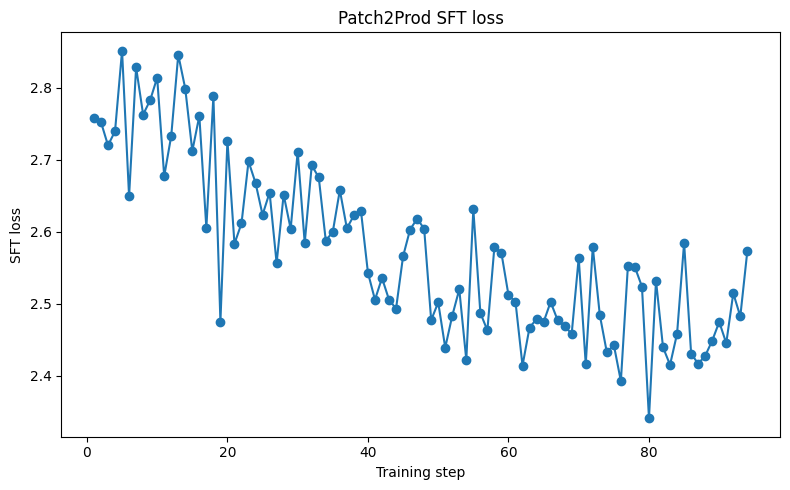

In [19]:
import matplotlib.pyplot as plt
from pathlib import Path
import json

Path("artifacts/plots").mkdir(parents=True, exist_ok=True)
log_history = trainer.state.log_history
loss_points = [{"step": x.get("step"), "value": x.get("loss")} for x in log_history if "loss" in x and x.get("step") is not None]
with open("artifacts/training_history.json", "w") as f:
    json.dump({"loss": loss_points}, f, indent=2)

if loss_points:
    steps=[p["step"] for p in loss_points]
    losses=[p["value"] for p in loss_points]
    plt.figure(figsize=(8,5))
    plt.plot(steps, losses, marker="o")
    plt.xlabel("Training step")
    plt.ylabel("SFT loss")
    plt.title("Patch2Prod SFT loss")
    plt.tight_layout()
    plt.savefig("artifacts/plots/loss_curve.png", dpi=160)
    plt.show()
else:
    print("No loss points found")

## 8. Save loss curve plot

This creates the required committed image: `artifacts/plots/loss_curve.png`.

In [20]:
import torch, json

model.eval()
if hasattr(model, "config"):
    model.config.use_cache = True

VALID_ACTION_NAMES = {"view_log","view_commit_history","view_diff","cat","view_migration_guide","view_security_advisory","replace","run_unit_tests","view_dependency_graph","mark_impacted_service","run_contract_tests","view_ownership_map","submit_causal_change","submit_blast_radius","submit_release_decision","view_reward"}

def trim_to_first_json_object(text):
    start=text.find("{")
    if start == -1:
        return text.strip()
    depth=0; in_str=False; escape=False
    for i in range(start, len(text)):
        ch=text[i]
        if escape:
            escape=False; continue
        if ch == "\\":
            escape=True; continue
        if ch == '"':
            in_str = not in_str; continue
        if not in_str:
            if ch == "{": depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return text[start:i+1].strip()
    return text[start:].strip()

REQUIRED_PARAMS = {
    "view_log": ["job_name"],
    "view_diff": ["commit_id"],
    "cat": ["file_path"],
    "replace": ["file_path", "search", "replace"],
    "run_unit_tests": ["service"],
    "view_dependency_graph": ["service"],
    "mark_impacted_service": ["service", "reason"],
    "run_contract_tests": ["service"],
    "submit_blast_radius": ["impacted_services"],
    "submit_release_decision": ["decision", "reason", "owner"],
    "view_commit_history": [],
    "view_migration_guide": [],
    "view_security_advisory": [],
    "view_ownership_map": [],
    "submit_causal_change": [],
    "view_reward": [],
}

def validate_generated_json(text):
    try:
        obj = json.loads(text)
    except Exception as e:
        return False, f"Invalid JSON: {e}", None

    action_type = obj.get("action_type")
    params = obj.get("params")

    if action_type not in VALID_ACTION_NAMES:
        return False, f"Invalid action_type: {action_type}", obj

    if not isinstance(params, dict):
        return False, "Missing or invalid params object", obj

    required = REQUIRED_PARAMS.get(action_type, [])
    missing = [p for p in required if p not in params]

    if missing:
        return False, f"Missing required params for {action_type}: {missing}", obj

    return True, "OK", obj

def generate_actions(prompt, max_new_tokens=450):
    full_prompt = "### Instruction:\n" + prompt.strip() + "\n\n### Response:\n"
    inputs = tokenizer(full_prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=6,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return trim_to_first_json_object(gen)

## 9. Quick generation sanity check

In [21]:
from pathlib import Path
import json

def make_test_prompt(task_id, service, failure):
    if task_id == "authsdk_mobile_contract_break":
        visible_state = {
            "task_id": task_id,
            "service": service,
            "pipeline_status": "failed",
            "failed_job": "unit-tests",
            "problem": "auth-service CI fails after authsdk v2 upgrade",
            "discovered": {},
            "validations": {},
        }
        step = 1

    elif task_id == "payment_schema_checkout_break":
        visible_state = {
            "task_id": task_id,
            "service": service,
            "pipeline_status": "failed",
            "failed_job": "integration-tests",
            "problem": "payment-service schema migration breaks checkout contract",
            "discovered": {},
            "validations": {},
        }
        step = 1

    else:
        visible_state = {
            "task_id": task_id,
            "service": service,
            "pipeline_status": "failed",
            "discovered": {},
            "validations": {},
        }
        step = 1

    return build_prompt(
        task_id=task_id,
        service=service,
        failure=failure,
        step=step,
        visible_state=visible_state,
        available_actions=AVAILABLE_ACTIONS,
    )

test_cases = [
    make_test_prompt(
        "authsdk_mobile_contract_break",
        "auth-service",
        "ImportError: cannot import name 'build_retry_policy' from authsdk.helpers",
    ),
    make_test_prompt(
        "authsdk_mobile_contract_break",
        "auth-service",
        "auth-service unit-tests fail after authsdk v2 migration because build_retry_policy is missing.",
    ),
    make_test_prompt(
        "payment_schema_checkout_break",
        "payment-service",
        "AssertionError: expected field 'payment_status', got 'status'.",
    ),
    make_test_prompt(
        "payment_schema_checkout_break",
        "payment-service",
        "integration-tests fail because checkout expects payment_status but payment-service returns status.",
    ),
]

valid_count = 0
outputs = []

for i, p in enumerate(test_cases, 1):
    out = generate_actions(p)
    ok, msg, obj = validate_generated_json(out)
    valid_count += int(ok)

    outputs.append({
        "case": i,
        "ok": ok,
        "msg": msg,
        "output": out,
    })

    print("=" * 80)
    print("CASE", i, ok, msg)
    print(out[:1500])

print("Valid JSON/action rate:", valid_count, "/", len(test_cases))

Path("artifacts/traces").mkdir(parents=True, exist_ok=True)
with open("artifacts/traces/sft_generation_samples.json", "w") as f:
    json.dump(outputs, f, indent=2)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


CASE 1 True OK
{
  "action_type": "view_log",
  "params": {
    "job_name": "unit-tests"
  }
}
CASE 2 True OK
{
  "action_type": "view_log",
  "params": {
    "job_name": "unit-tests"
  }
}
CASE 3 True OK
{
  "action_type": "view_log",
  "params": {
    "job_name": "integration-tests"
  }
}
CASE 4 True OK
{
  "action_type": "view_log",
  "params": {
    "job_name": "integration-tests"
  }
}
Valid JSON/action rate: 4 / 4


In [49]:
import json

with open("artifacts/traces/sft_trace.json") as f:
    trace = json.load(f)

for result in trace["results"]:
    print("\nTASK:", result["task_id"])
    print("TOTAL REWARD:", result["total_reward"], "DONE:", result["done"])
    for step in result["steps"]:
        print(
            "STEP", step["step"],
            "| valid:", step["valid_generation"],
            "| msg:", step["validation_message"],
            "| action:", step.get("action"),
            "| reward:", step.get("reward"),
        )
        print("RAW:", step["raw_generation"][:300])
        print("-" * 80)


TASK: authsdk_mobile_contract_break
TOTAL REWARD: -0.71 DONE: False
STEP 1 | valid: True | msg: OK | action: {'action_type': 'view_diff', 'params': {'commit_id': 'c43'}} | reward: -0.07
RAW: {"action_type":"view_diff","params":{"commit_id":"c43"}}
--------------------------------------------------------------------------------
STEP 2 | valid: True | msg: OK | action: {'action_type': 'view_diff', 'params': {'commit_id': 'c43'}} | reward: -0.07
RAW: {"action_type":"view_diff","params":{"commit_id":"c43"}}
--------------------------------------------------------------------------------
STEP 3 | valid: True | msg: OK | action: {'action_type': 'view_diff', 'params': {'commit_id': 'c43'}} | reward: -0.07
RAW: {"action_type":"view_diff","params":{"commit_id":"c43"}}
--------------------------------------------------------------------------------
STEP 4 | valid: False | msg: Missing required params for run_unit_tests: ['service'] | action: {'action_type': 'run_unit_tests', 'params': {}} | rew

In [22]:
!python training/evaluate_sft_policy.py \
  --model outputs/sft_patch2prod_lora \
  --base_model Qwen/Qwen2.5-0.5B-Instruct \
  --tasks data/eval_tasks.jsonl \
  --out artifacts/traces/sft_trace.json \
  --max_steps 18

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█| 290/290 [00:00<00:00, 744.53it/s, Materializing param=m
Evaluating task: authsdk_mobile_contract_break
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
  reward=3.09 done=True
Evaluating task: payment_schema_checkout_break
  reward=3.09 done=True
{
  "out": "artifacts/traces/sft_trace.json",
  "metrics": {
    "num_tasks": 2,
    "avg_reward": 3.09,
    "completion_rate": 1.0,
    "ci_repair_success_rate": 0.0,
    "correct_release_decision_rate": 0.0,
    "unsafe_ship_rate": 0.0,
    "valid_action_rate": 1.0
  }
}


In [ ]:
!mkdir -p artifacts/traces artifacts/plots
!python training/evaluate.py   --policy model   --model outputs/sft_patch2prod_lora   --tasks data/eval_tasks.jsonl   --out artifacts/traces/sft_trace.json   --max_steps 20 || true

## 10. Evaluate SFT checkpoint in the environment

This requires your `training/evaluate.py` to support `--policy model`.

In [20]:
print(dataset[0]["text"])

### Instruction:
Task authsdk_mobile_break_001: auth-service CI failed after authsdk upgrade. Return JSON actions only.

### Response:
{"actions":[{"action":"view_log","job_name":"unit-tests"},{"action":"view_diff","commit_id":"c42"},{"action":"grep","pattern":"build_retry_policy","path":"."},{"action":"replace","file_path":"services/auth-service/app/retry.py","search":"build_retry_policy","replace":"create_retry_policy"},{"action":"run_unit_tests","service":"auth-service"},{"action":"view_dependency_graph","service":"auth-service"},{"action":"run_contract_tests","service":"mobile-gateway"},{"action":"submit_release_decision","decision":"block","reason":"mobile-gateway contract fails after token expiry format change","owner":"mobile-platform"}]}


In [ ]:
!mkdir -p artifacts/traces
!python training/evaluate.py   --policy model   --model outputs/sft_patch2prod   --tasks data/eval_tasks.jsonl   --out artifacts/traces/sft_trace.json   --max_steps 20

!cat artifacts/traces/sft_trace.json | head -80

## 11. Generate reward/eval plots

Generated plots:
  - artifacts/plots/baseline_vs_improved.png
  - artifacts/plots/baseline_vs_trained.png
  - artifacts/plots/loss_curve.png
  - artifacts/plots/reward_curve.png
  - artifacts/plots/unsafe_ship_rate.png
Metrics summary: artifacts/metrics_summary.json
artifacts/plots/loss_curve.png


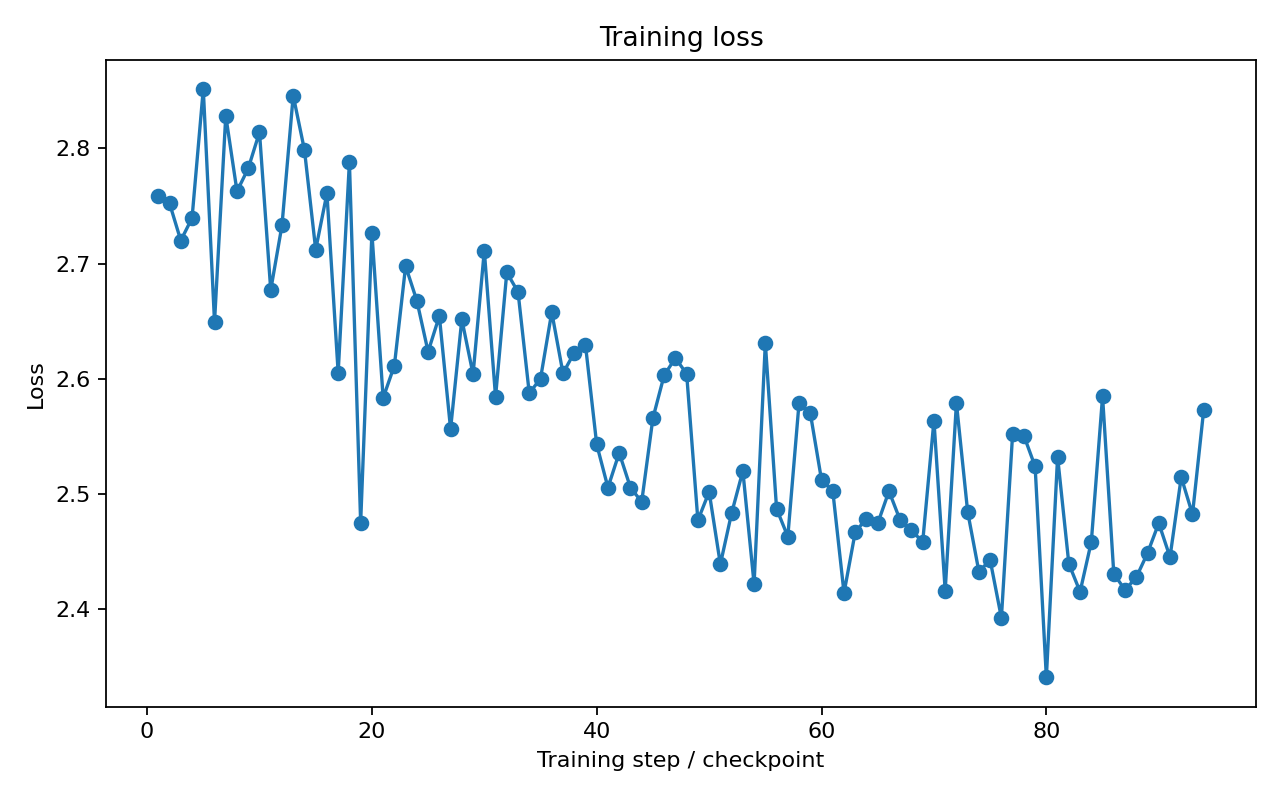

artifacts/plots/reward_curve.png


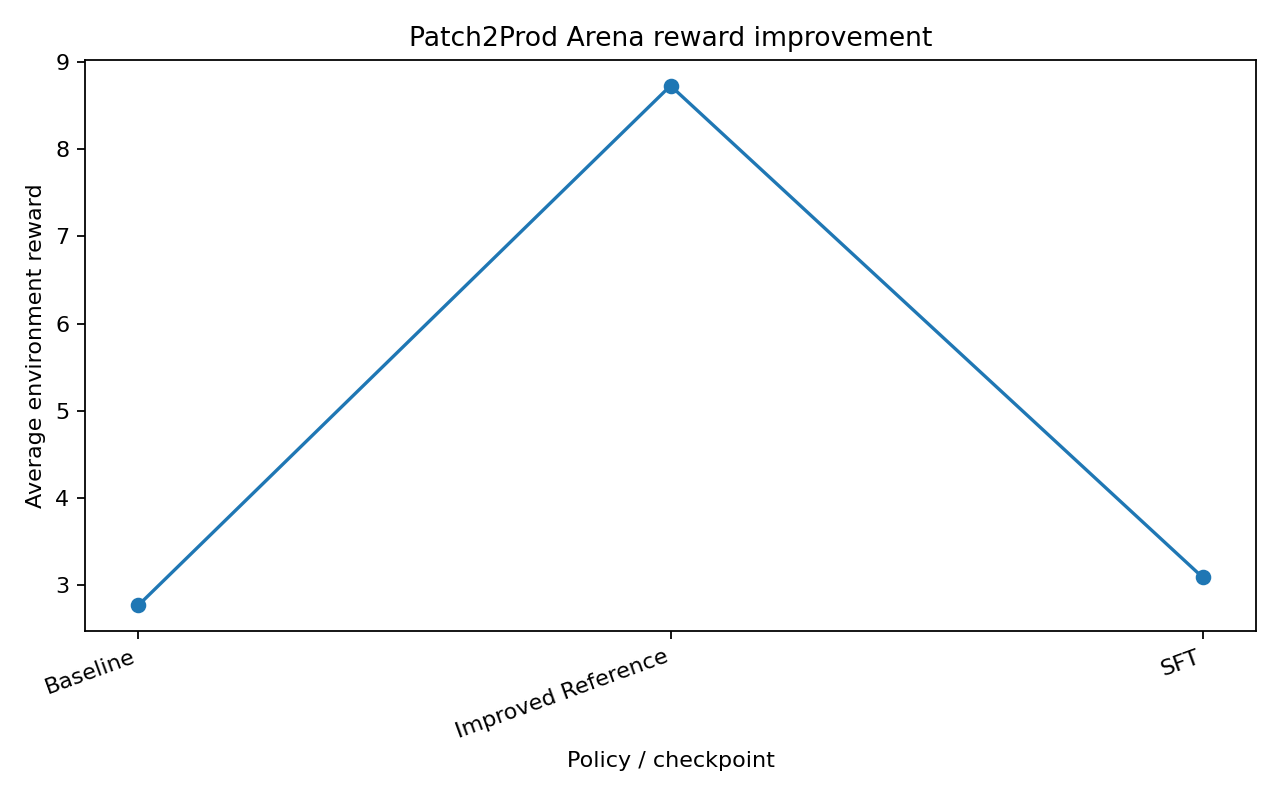

artifacts/plots/baseline_vs_trained.png


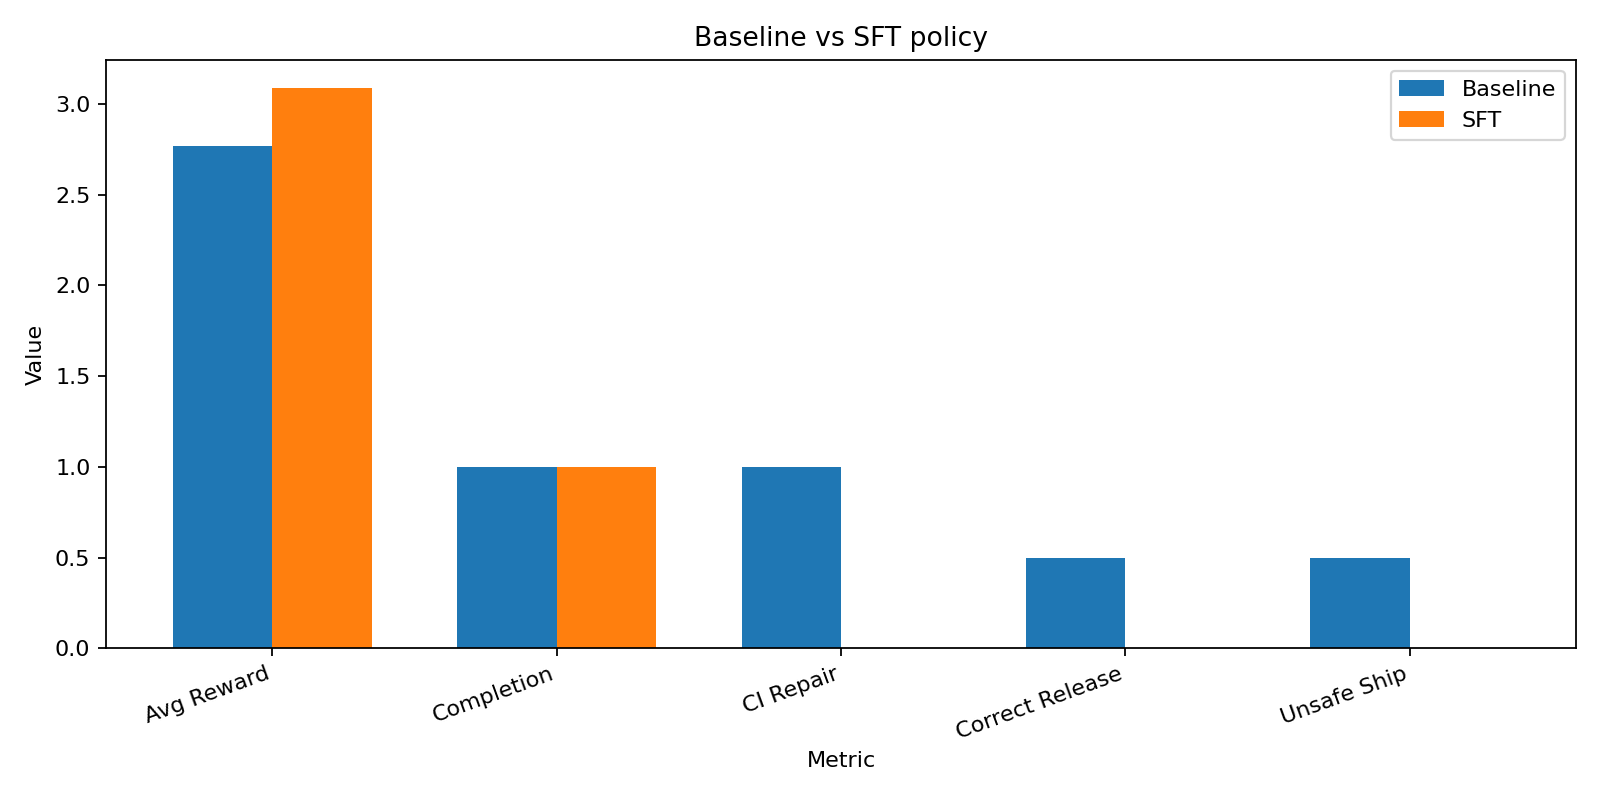

In [23]:
!python training/generate_plots.py

from pathlib import Path
from IPython.display import Image, display
for p in ['artifacts/plots/loss_curve.png', 'artifacts/plots/reward_curve.png', 'artifacts/plots/baseline_vs_trained.png']:
    if Path(p).exists():
        print(p)
        display(Image(filename=p))

## 12. Optional: push SFT model to Hugging Face Hub

In [25]:
PUSH_TO_HUB = True
REPO_ID = 'madhuria/patch2prod-sft-agent'

if PUSH_TO_HUB:
    model.push_to_hub(REPO_ID)
    tokenizer.push_to_hub(REPO_ID)
    print('Pushed to', REPO_ID)
else:
    print('Skipping push. Set PUSH_TO_HUB=True to upload.')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed to madhuria/patch2prod-sft-agent


## 13. Download plots/traces if needed

In [ ]:
from google.colab import files

# Uncomment whichever files you want to download locally and commit.
# files.download('artifacts/plots/loss_curve.png')
# files.download('artifacts/plots/reward_curve.png')
# files.download('artifacts/plots/baseline_vs_trained.png')
# files.download('artifacts/traces/sft_trace.json')
# files.download('artifacts/training_history.json')

In [46]:
from google.colab import files

files.download('artifacts/traces/sft_generation_samples.json')
files.download('artifacts/training_history.json')
files.download('artifacts/plots/loss_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>